# CVD Accessibility — Results

End-to-end walkthrough: load an image, simulate color vision deficiency,
score its accessibility, correct it (rule-based daltonization and a
self-supervised U-Net), and compare results.

See `research_log.md` for full methodology, findings, and limitations.

In [2]:
import os
os.chdir('..')  # run from project root so relative imports/paths work

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

from src.utils import load_image_rgb_normalized
from src.simulate import simulate_cvd, PROTANOPIA_MATRIX
from src.metrics import accessibility_score, print_accessibility_report, extract_dominant_colors
from src.daltonize import daltonize, PROTANOPIA_CORRECTION_MATRIX
from src.train import train
from src.differentiable import PROTANOPIA_MATRIX_TORCH

## 1. Load test image

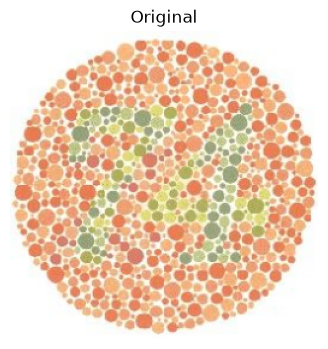

In [3]:
img = load_image_rgb_normalized('data/test_images/74_img.jpg')  # adjust filename as needed
img_resized = cv2.resize(img, (256, 256))  # divisible by 8, needed for U-Net

plt.figure(figsize=(4,4))
plt.imshow(np.clip(img_resized, 0, 1))
plt.title('Original')
plt.axis('off')
plt.show()

## 2. Simulate protanopia

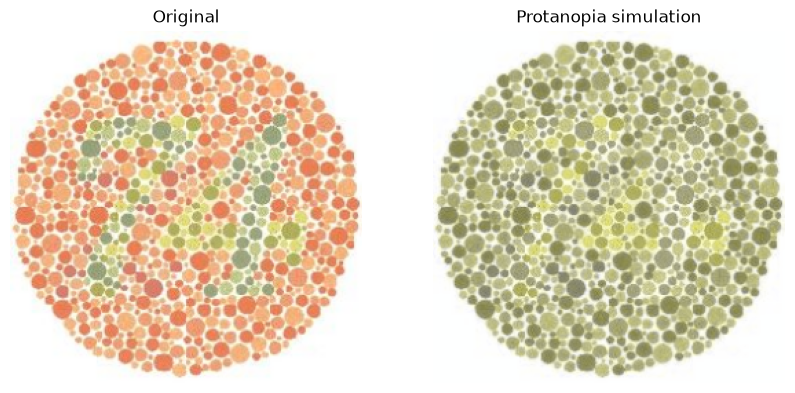

In [4]:
simulated = simulate_cvd(img_resized, PROTANOPIA_MATRIX)

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(np.clip(img_resized, 0, 1)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(np.clip(simulated, 0, 1)); axes[1].set_title('Protanopia simulation'); axes[1].axis('off')
plt.show()

## 3. Baseline accessibility score

In [5]:
baseline_result = accessibility_score(img_resized, PROTANOPIA_MATRIX, k=4)
print_accessibility_report(baseline_result, 'Original (protanopia)')

--- Accessibility Report: Original (protanopia) ---
Overall score (worst-case pair Delta-E): 8.96
No critically confusable pair found

  normal_diff= 18.38  cvd_diff=  8.96  colors=[0.91 0.7  0.55] vs [0.86 0.81 0.64]
  normal_diff= 19.75  cvd_diff= 13.88  colors=[0.88 0.54 0.4 ] vs [0.91 0.7  0.55]
  normal_diff= 37.75  cvd_diff= 22.72  colors=[0.88 0.54 0.4 ] vs [0.86 0.81 0.64]
  normal_diff= 25.98  cvd_diff= 26.35  colors=[1.   0.99 0.96] vs [0.86 0.81 0.64]
  normal_diff= 35.56  cvd_diff= 32.05  colors=[1.   0.99 0.96] vs [0.91 0.7  0.55]
  normal_diff= 53.64  cvd_diff= 44.43  colors=[1.   0.99 0.96] vs [0.88 0.54 0.4 ]


## 4. Rule-based daltonization

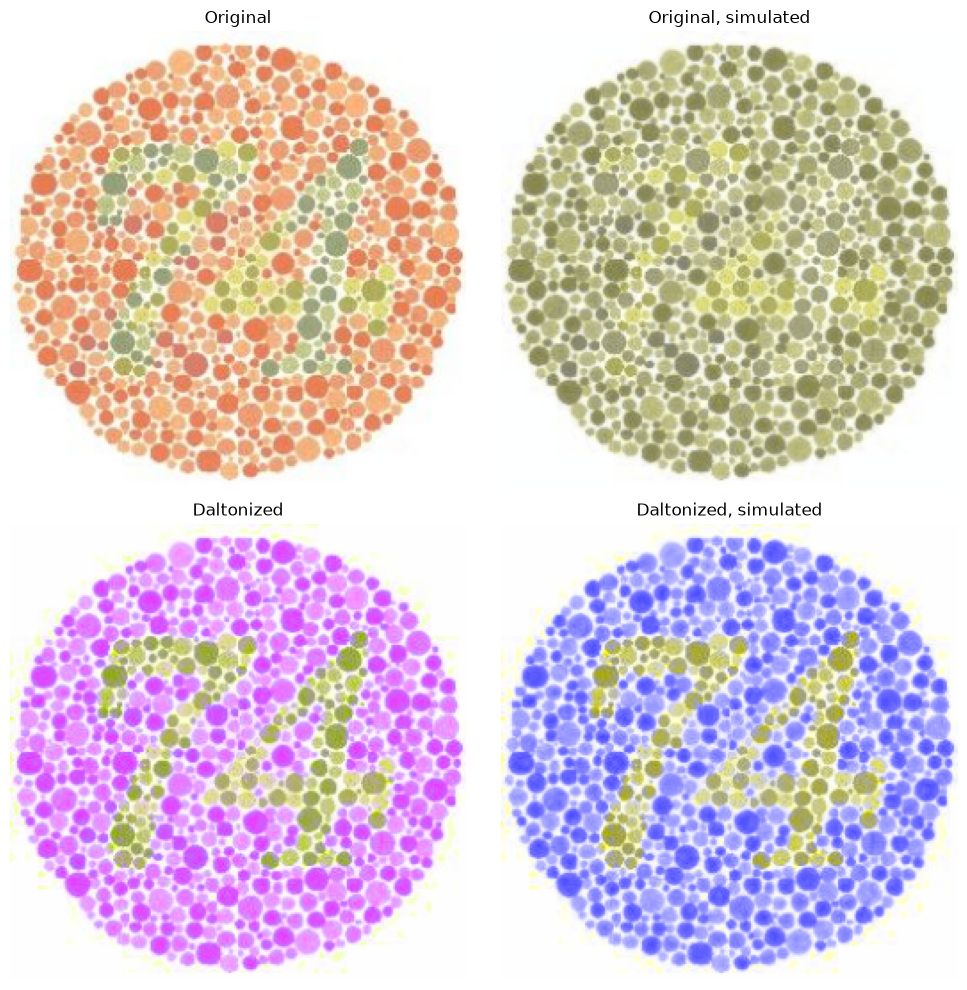

--- Accessibility Report: Daltonized (protanopia) ---
Overall score (worst-case pair Delta-E): 29.17
No critically confusable pair found

  normal_diff= 27.52  cvd_diff= 29.17  colors=[0.86 0.39 1.  ] vs [0.88 0.58 1.  ]
  normal_diff= 31.40  cvd_diff= 29.81  colors=[0.93 0.77 1.  ] vs [0.88 0.58 1.  ]
  normal_diff= 41.17  cvd_diff= 37.50  colors=[0.93 0.77 1.  ] vs [0.93 0.92 0.87]
  normal_diff= 58.81  cvd_diff= 58.88  colors=[0.93 0.77 1.  ] vs [0.86 0.39 1.  ]
  normal_diff= 72.09  cvd_diff= 66.79  colors=[0.93 0.92 0.87] vs [0.88 0.58 1.  ]
  normal_diff= 99.24  cvd_diff= 95.59  colors=[0.86 0.39 1.  ] vs [0.93 0.92 0.87]


In [6]:
corrected = daltonize(img_resized, PROTANOPIA_MATRIX, PROTANOPIA_CORRECTION_MATRIX)

fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes[0,0].imshow(np.clip(img_resized,0,1)); axes[0,0].set_title('Original'); axes[0,0].axis('off')
axes[0,1].imshow(np.clip(simulate_cvd(img_resized, PROTANOPIA_MATRIX),0,1)); axes[0,1].set_title('Original, simulated'); axes[0,1].axis('off')
axes[1,0].imshow(np.clip(corrected,0,1)); axes[1,0].set_title('Daltonized'); axes[1,0].axis('off')
axes[1,1].imshow(np.clip(simulate_cvd(corrected, PROTANOPIA_MATRIX),0,1)); axes[1,1].set_title('Daltonized, simulated'); axes[1,1].axis('off')
plt.tight_layout(); plt.show()

dalton_result = accessibility_score(corrected, PROTANOPIA_MATRIX, k=4)
print_accessibility_report(dalton_result, 'Daltonized (protanopia)')

## 5. U-Net learned correction

epoch    0  loss=0.6443  distortion=0.6645  accessibility_gain=0.2018
epoch   20  loss=0.2158  distortion=0.2531  accessibility_gain=0.3727
epoch   40  loss=0.0876  distortion=0.1229  accessibility_gain=0.3528
epoch   60  loss=0.0292  distortion=0.0660  accessibility_gain=0.3678
epoch   80  loss=0.0019  distortion=0.0391  accessibility_gain=0.3712
epoch  100  loss=-0.0092  distortion=0.0281  accessibility_gain=0.3729
epoch  120  loss=-0.0133  distortion=0.0243  accessibility_gain=0.3756
epoch  140  loss=-0.0148  distortion=0.0231  accessibility_gain=0.3785
epoch  160  loss=-0.0154  distortion=0.0226  accessibility_gain=0.3794
epoch  180  loss=-0.0156  distortion=0.0223  accessibility_gain=0.3797
epoch  199  loss=-0.0158  distortion=0.0222  accessibility_gain=0.3800

Loaded checkpoint with lowest distortion: 0.0222


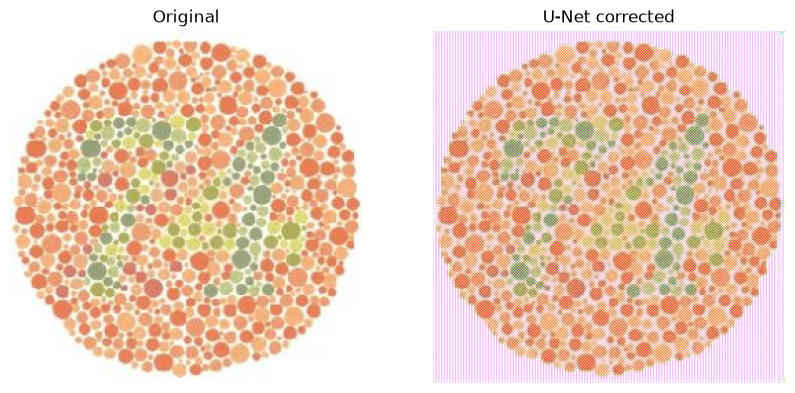

--- Accessibility Report: U-Net corrected (protanopia) ---
Overall score (worst-case pair Delta-E): 31.48
No critically confusable pair found

  normal_diff= 35.16  cvd_diff= 31.48  colors=[0.85 0.44 0.52] vs [0.95 0.72 0.91]
  normal_diff= 39.36  cvd_diff= 39.34  colors=[1.   1.   0.89] vs [0.91 0.91 0.5 ]
  normal_diff= 48.59  cvd_diff= 42.90  colors=[1.   1.   0.89] vs [0.95 0.72 0.91]
  normal_diff= 62.71  cvd_diff= 51.58  colors=[1.   1.   0.89] vs [0.85 0.44 0.52]
  normal_diff= 78.36  cvd_diff= 69.71  colors=[0.85 0.44 0.52] vs [0.91 0.91 0.5 ]
  normal_diff= 80.27  cvd_diff= 76.37  colors=[0.95 0.72 0.91] vs [0.91 0.91 0.5 ]


In [8]:
img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
model = train(img_tensor, cvd_matrix=PROTANOPIA_MATRIX_TORCH, epochs=200, lam=0.1)

model.eval()
with torch.no_grad():
    unet_corrected = model(img_tensor).squeeze(0).permute(1,2,0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(np.clip(img_resized,0,1)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(np.clip(unet_corrected,0,1)); axes[1].set_title('U-Net corrected'); axes[1].axis('off')
plt.show()

unet_result = accessibility_score(unet_corrected, PROTANOPIA_MATRIX, k=4)
print_accessibility_report(unet_result, 'U-Net corrected (protanopia)')

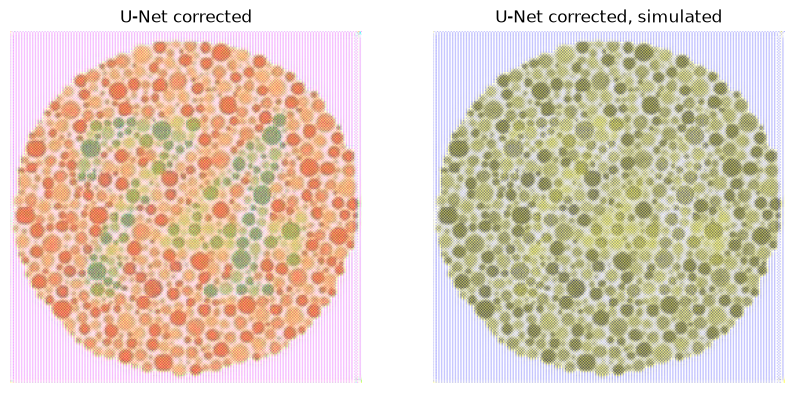

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(np.clip(unet_corrected, 0, 1))
axes[0].set_title('U-Net corrected')
axes[1].imshow(np.clip(simulate_cvd(unet_corrected, PROTANOPIA_MATRIX), 0, 1))
axes[1].set_title('U-Net corrected, simulated')
for ax in axes: ax.axis('off')
plt.show()

## 6. Summary

| Version | Overall Score | Notes |
|---|---|---|
| Original | ~8.96 | A little above JND threshold - number and background confusable |
| Rule-based daltonization | ~29.17 | Clean, faithful correction |
| U-Net (tuned) | ~31.48 | Improvement over original, but visual artifacts present (see research_log.md) |

See `research_log.md` for full discussion of methodology, findings, and limitations.